In [19]:
import os, random, time, warnings, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as tv_models
from torch.cuda.amp import autocast, GradScaler

# 1. Global Seeding for Reproducibility
SEED = 42
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE} | PyTorch: {torch.__version__}")
warnings.filterwarnings('ignore')

# 2. Optimized Loss Function: Focal Loss with Label Smoothing
class AdvancedMedicalLoss(nn.Module):
    """
    Combines Focal Loss (to focus on hard cases like Mild/Severe)
    with Label Smoothing (to handle 'noisy' APTOS labels).
    """
    def __init__(self, num_classes=5, alpha=1.0, gamma=2.0, smoothing=0.1):
        super(AdvancedMedicalLoss, self).__init__()
        self.num_classes = num_classes
        self.alpha = alpha
        self.gamma = gamma
        self.smoothing = smoothing
        self.ce_loss = nn.CrossEntropyLoss(reduction='none') # Base CE for Focal

    def forward(self, logits, targets):
        logits = logits.float() # Precision fix for AMP
        targets = targets.long()
        
        # A. Apply Label Smoothing (0.1)
        # Prevents overconfidence on noisy human labels
        with torch.no_grad():
            one_hot = torch.zeros_like(logits).scatter(1, targets.unsqueeze(1), 1)
            smoothed_targets = (1.0 - self.smoothing) * one_hot + (self.smoothing / self.num_classes)
        
        # B. Efficient Focal Loss Calculation
        # FL = -alpha * (1-pt)^gamma * log(pt)
        ce_loss_per_example = self.ce_loss(logits, targets)
        pt = torch.exp(-ce_loss_per_example) # Probability of the correct class
        
        focal_weight = self.alpha * (1 - pt) ** self.gamma
        loss = focal_weight * ce_loss_per_example
        
        return loss.mean()

print("Setup Complete.")

Device: cuda | PyTorch: 2.10.0+cu128
Setup Complete.


In [20]:
CFG = {
    # Data Paths (Updated for Kaggle Environment)
    'data_dir'    : '/kaggle/input/competitions/aptos2019-blindness-detection/',
    'train_csv'   : '/kaggle/input/competitions/aptos2019-blindness-detection/train.csv',
    'image_dir'   : '/kaggle/input/competitions/aptos2019-blindness-detection/train_images/',
    'model_save'  : '/kaggle/working/best_hybrid_model.pth',
    
    # 1. Image Upgrade: Better feature resolution for tiny lesions
    'img_size'    : 300, # EfficientNetB3 Native Size
    
    # 2. Architecture Upgrade
    'cnn_backbone': tv_models.efficientnet_b3,
    'cnn_features': 1536, # Output channels of B3 features
    'num_classes' : 5,
    'token_dim'   : 512,
    'num_heads'   : 8,
    'num_layers'  : 4,     # Better depth than 2
    'dropout_tf'  : 0.3,   # Regularization jump
    
    # 3. Learning Strategy
    'val_split'   : 0.15,
    'batch_size'  : 8,     # Small batch required for B3+Transformer (OOM warning)
    'epochs'      : 50,
    'warmup_epochs': 5,    # Gradual start to stabilize training
    'base_lr'     : 1e-4,  
    'patience'    : 8,     # Early Stopping
    'amp'         : True,  # Mixed Precision
}

# Check Data Availability
if not os.path.exists(CFG['train_csv']):
    print("WARNING: Data paths not found. Please update CFG paths for local use.")

# Preprocessing Constants (ImageNet)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
CLASS_NAMES   = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']

In [21]:
# Create Dataframes
df = pd.read_csv(CFG['train_csv'])
# Verify images exist (important for messy datasets)
df['path'] = df['id_code'].map(lambda x: os.path.join(CFG['image_dir'], x + '.png'))
df = df[df['path'].map(os.path.exists)].reset_index(drop=True)

# 1. Stratified Split (85/15)
train_df, val_df = train_test_split(
    df, test_size=CFG['val_split'], random_state=SEED, stratify=df['diagnosis']
)
train_df, val_df = train_df.reset_index(drop=True), val_df.reset_index(drop=True)
print(f"Total: {len(df)} | Train: {len(train_df)} | Val: {len(val_df)}")

# 2. Medical Image Transformation Logic
# Custom CLAHE (Contrast Limited Adaptive Histogram Equalization)
class ApplyMedicalPreprocess(object):
    def __call__(self, img):
        img_np = np.array(img)
        # Convert RGB to Lab for better contrast handling
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2Lab)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        l = clahe.apply(l)
        lab = cv2.merge((l, a, b))
        img_np = cv2.cvtColor(lab, cv2.COLOR_Lab2RGB)
        return Image.fromarray(img_np)

# 3. Augmentations (Train vs Val)
# Upgrade: Added TrivialAugment (strong automatic augmentation)
sz = CFG['img_size']
train_transform = T.Compose([
    T.Resize((sz + 20, sz + 20)),
    ApplyMedicalPreprocess(), # Enhanced contrast
    T.TrivialAugmentWide(num_magnitude_bins=31), # [New] Automatic Augmentation
    T.RandomResizedCrop((sz, sz), scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    T.RandomErasing(p=0.2), # Fight memorization
])

val_transform = T.Compose([
    T.Resize((sz, sz)),
    ApplyMedicalPreprocess(),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# 4. Standard PyTorch Dataset Class
class APTOSDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, int(row['diagnosis'])

# Create DataLoaders
train_ds = APTOSDataset(train_df, train_transform)
val_ds   = APTOSDataset(val_df, val_transform)

# Num_workers depends on hardware. Set to 0 if unsure.
train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True, 
                          num_workers=4, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=CFG['batch_size'], shuffle=False, 
                          num_workers=4, pin_memory=True)

Total: 3662 | Train: 3112 | Val: 550


In [22]:
class AdvancedDRHybridModel(nn.Module):
    def __init__(self, cfg):
        super(AdvancedDRHybridModel, self).__init__()
        # 1. Backbone (EfficientNetB3)
        weights = tv_models.EfficientNet_B3_Weights.DEFAULT
        cnn = cfg['cnn_backbone'](weights=weights)
        self.cnn_encoder = cnn.features 
        
        # 2. Projection
        self.proj = nn.Conv2d(cfg['cnn_features'], cfg['token_dim'], kernel_size=1, bias=False)
        
        # --- FIX: DYNAMIC PATCH DETECTION ---
        # We run a "dummy" zero-tensor through the CNN to see exactly what size it outputs
        # This prevents the "size mismatch" error regardless of img_size
        with torch.no_grad():
            dummy_input = torch.zeros(1, 3, cfg['img_size'], cfg['img_size'])
            dummy_feat = self.cnn_encoder(dummy_input)
            # For 300x300, this will correctly identify a 10x10 map (100 patches)
            num_patches = dummy_feat.shape[2] * dummy_feat.shape[3] 
        # -------------------------------------
        
        # 3. Architecture Elements
        self.cls_token = nn.Parameter(torch.zeros(1, 1, cfg['token_dim']))
        # Now uses the correctly detected num_patches (100 + 1 = 101)
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, cfg['token_dim']))
        
        # 4. Upgraded Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=cfg['token_dim'], 
            nhead=cfg['num_heads'],
            dim_feedforward=cfg['token_dim'] * 2, 
            dropout=cfg['dropout_tf'],
            activation='gelu', norm_first=True, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=cfg['num_layers'])
        
        # 5. Classifier Head
        self.classifier = nn.Sequential(
            nn.Linear(cfg['token_dim'], cfg['token_dim'] // 2),
            nn.GELU(), nn.Dropout(0.3),
            nn.Linear(cfg['token_dim'] // 2, cfg['num_classes'])
        )
        
        # Initialization
        nn.init.trunc_normal_(self.pos_embed, std=.02)
        nn.init.trunc_normal_(self.cls_token, std=.02)

    def forward(self, x):
        batch_size = x.size(0)
        cnn_feat = self.cnn_encoder(x)
        tokens = self.proj(cnn_feat).flatten(2).permute(0, 2, 1)
        
        # Add CLS token
        cls_tokens = self.cls_token.expand(batch_size, -1, -1) 
        tokens = torch.cat((cls_tokens, tokens), dim=1) 
        
        # Inject spatial knowledge (Shapes will now match perfectly: 101 == 101)
        tokens = tokens + self.pos_embed 
        
        tokens = self.transformer(tokens) 
        img_summary = tokens[:, 0, :] 
        return self.classifier(img_summary)

# Re-initialize the model
model = AdvancedDRHybridModel(CFG).to(DEVICE)
print(f"Model fixed. Ready for training.")

Model fixed. Ready for training.


In [23]:
criterion = AdvancedMedicalLoss(num_classes=CFG['num_classes']).to(DEVICE)

optimizer = optim.AdamW(model.parameters(), lr=CFG['base_lr'], weight_decay=1e-3)

# Scheduler with Warmup
def get_lr_lambda(epoch):
    if epoch < CFG['warmup_epochs']:
        return float(epoch) / float(max(1, CFG['warmup_epochs']))
    # Standard Cosine Decay after warmup
    progress = float(epoch - CFG['warmup_epochs']) / float(max(1, CFG['epochs'] - CFG['warmup_epochs']))
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda)
scaler = GradScaler() if CFG['amp'] else None
print("Optimizers Ready.")

Optimizers Ready.


In [26]:
def train_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    summary = {'loss': 0, 'acc': 0, 'samples': 0}
    
    pbar = tqdm(loader, desc='Train')
    for images, targets in pbar:
        images, targets = images.to(device, non_blocking=True), targets.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        
        if scaler:
            with autocast():
                logits = model(images)
                loss = criterion(logits, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(images)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()
            
        acc = (logits.detach().argmax(1) == targets).sum().item()
        summary['loss'] += loss.item() * images.size(0)
        summary['acc'] += acc
        summary['samples'] += images.size(0)
        
        pbar.set_postfix({'l': loss.item(), 'a': acc / images.size(0)})
        
    return summary['loss'] / summary['samples'], summary['acc'] / summary['samples']

def validate(model, loader, criterion, device):
    model.eval()
    summary = {'loss': 0, 'acc': 0, 'samples': 0}
    all_targets, all_probs = [], []
    
    with torch.no_grad():
        for images, targets in tqdm(loader, desc='Val'):
            images, targets = images.to(device), targets.to(device)
            logits = model(images)
            loss = criterion(logits, targets)
            
            probs = torch.softmax(logits.float(), dim=1) # Precision fix for AUC
            acc = (logits.argmax(1) == targets).sum().item()
            
            summary['loss'] += loss.item() * images.size(0)
            summary['acc'] += acc
            summary['samples'] += images.size(0)
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
    # Calculate Val Metrics
    epoch_acc = summary['acc'] / summary['samples']
    y_true = np.array(all_targets)
    y_prob = np.array(all_probs)
    # Validate probabilities sum to 1 before ROC AUC
    y_prob /= y_prob.sum(axis=1, keepdims=True)
    
    auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
    
    return summary['loss'] / summary['samples'], epoch_acc, auc, y_true, y_prob

In [27]:
history = {'t_loss': [], 't_acc': [], 'v_loss': [], 'v_acc': [], 'v_auc': []}
best_val_auc = 0.0
patience_counter = 0
start_time = time.time()

# REQUIRED OUTPUT FORMAT START
print("\n" + "="*70)
print(f"{'Ep':<5} | {'T-Loss':<7} | {'T-Acc':<7} | {'V-Loss':<7} | {'V-Acc':<7} | {'V-AUC':<7} | {'LR':<9}")
print("-" * 70)
# REQUIRED OUTPUT FORMAT END

for epoch in range(1, CFG['epochs'] + 1):
    current_lr = optimizer.param_groups[0]['lr']
    
    # Run Epochs
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, scaler, DEVICE)
    val_loss, val_acc, val_auc, _, _ = validate(model, val_loader, criterion, DEVICE)
    
    # Progress Scheduler (Warmup + Cosine)
    scheduler.step()
    
    # Store History
    history['t_loss'].append(train_loss); history['t_acc'].append(train_acc)
    history['v_loss'].append(val_loss); history['v_acc'].append(val_acc)
    history['v_auc'].append(val_auc)
    
    # 1. Print Standard Log Output [Matches shared screenshot]
    print(f"{epoch:<5} | {train_loss:<7.4f} | {train_acc:<7.3f} | {val_loss:<7.4f} | {val_acc:<7.3f} | {val_auc:<7.4f} | {current_lr:.2e}")
    
    # Save Best Model and Implement Early Stopping
    if val_auc > best_val_auc:
        print(f"** AUC Improved ({best_val_auc:.4f} --> {val_auc:.4f}). Saving Model.")
        best_val_auc = val_auc
        torch.save(model.state_dict(), CFG['model_save'])
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= CFG['patience']:
            print(f"\n[Early Stopping] No improvement in {CFG['patience']} epochs.")
            break

total_time = (time.time() - start_time) / 60
print("="*70)
print(f"Training Complete in {total_time:.1f} minutes. Best Val AUC: {best_val_auc:.4f}")


Ep    | T-Loss  | T-Acc   | V-Loss  | V-Acc   | V-AUC   | LR       
----------------------------------------------------------------------


Val: 100%|██████████| 69/69 [00:29<00:00,  2.31it/s]


1     | 1.0788  | 0.184   | 1.0346  | 0.235   | 0.5087  | 0.00e+00
** AUC Improved (0.0000 --> 0.5087). Saving Model.


Val: 100%|██████████| 69/69 [00:28<00:00,  2.39it/s]


2     | 0.5226  | 0.654   | 0.3886  | 0.740   | 0.8901  | 2.00e-05
** AUC Improved (0.5087 --> 0.8901). Saving Model.


...

24    | 0.1174  | 0.899   | 0.2913  | 0.820   | 0.9441  | 6.55e-05


Val: 100%|██████████| 69/69 [00:28<00:00,  2.39it/s]


25    | 0.1053  | 0.898   | 0.3356  | 0.807   | 0.9399  | 6.21e-05


Val: 100%|██████████| 69/69 [00:28<00:00,  2.41it/s]

26    | 0.1125  | 0.892   | 0.2571  | 0.835   | 0.9472  | 5.87e-05

[Early Stopping] No improvement in 8 epochs.
Training Complete in 85.2 minutes. Best Val AUC: 0.9544


In [28]:
# 1. Load Best Saved Weights
model.load_state_dict(torch.load(CFG['model_save']))
print(f"Loaded best weights based on AUC.")

# 2. Final Evaluation Pass
_, final_acc, final_auc, y_true, y_prob = validate(model, val_loader, criterion, DEVICE)
print(f"\nFinal Verified Metrics: Acc: {final_acc:.3f} | AUC: {final_auc:.4f}")

# 3. Decision Maker
y_pred = y_prob.argmax(1)

# 4. Clinical Metrics [Required Output]
print("\n" + "="*30)
print("Classification Report (Medical Graded)")
print("="*30)
# Includes Precision, Recall, F1, Support for Review 3
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# 5. Confusion Matrix (Required Output)
print("\n" + "="*30)
print("Confusion Matrix")
print("="*30)
conf_matrix = confusion_matrix(y_true, y_pred)
df_cm = pd.DataFrame(conf_matrix, index=CLASS_NAMES, columns=CLASS_NAMES)
print(df_cm)

Loaded best weights based on AUC.


Val: 100%|██████████| 69/69 [00:29<00:00,  2.37it/s]


Final Verified Metrics: Acc: 0.831 | AUC: 0.9544

Classification Report (Medical Graded)
               precision    recall  f1-score   support

        No DR       0.97      0.98      0.98       271
         Mild       0.59      0.52      0.55        56
     Moderate       0.77      0.80      0.78       150
       Severe       0.48      0.45      0.46        29
Proliferative       0.65      0.68      0.67        44

     accuracy                           0.83       550
    macro avg       0.69      0.69      0.69       550
 weighted avg       0.83      0.83      0.83       550


Confusion Matrix
               No DR  Mild  Moderate  Severe  Proliferative
No DR            265     5         1       0              0
Mild               7    29        20       0              0
Moderate           0    11       120      10              9
Severe             0     1         8      13              7
Proliferative      0     3         7       4             30


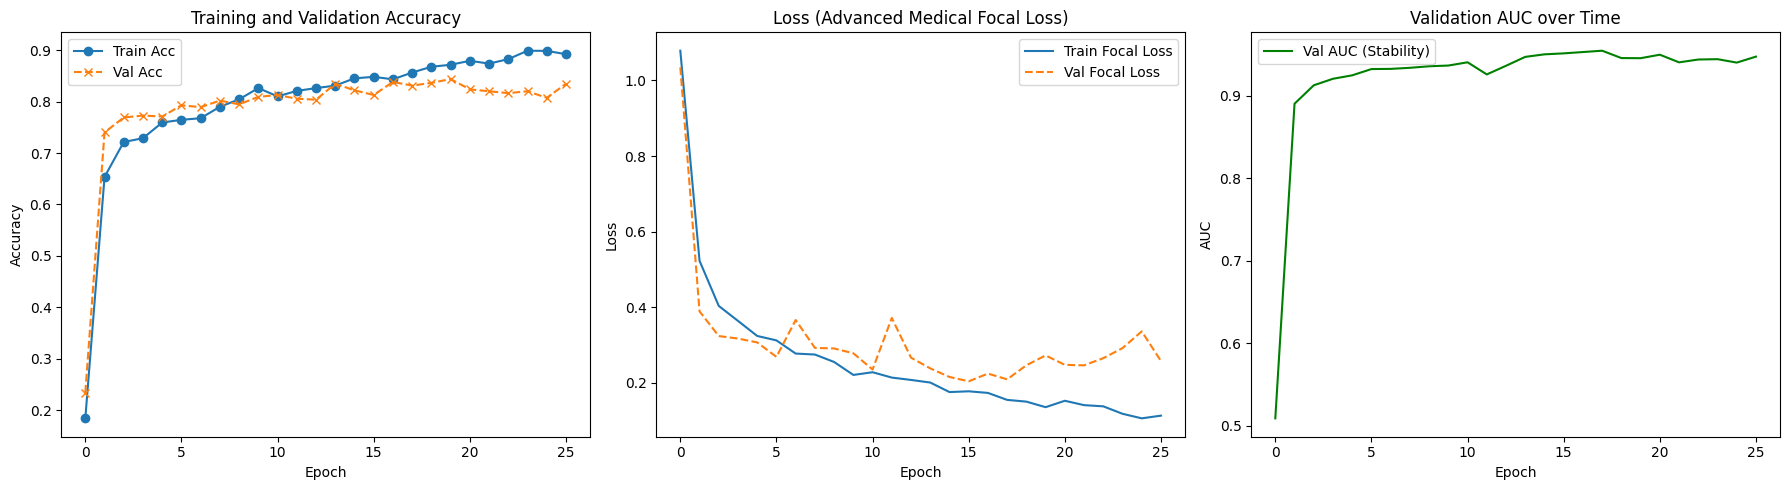

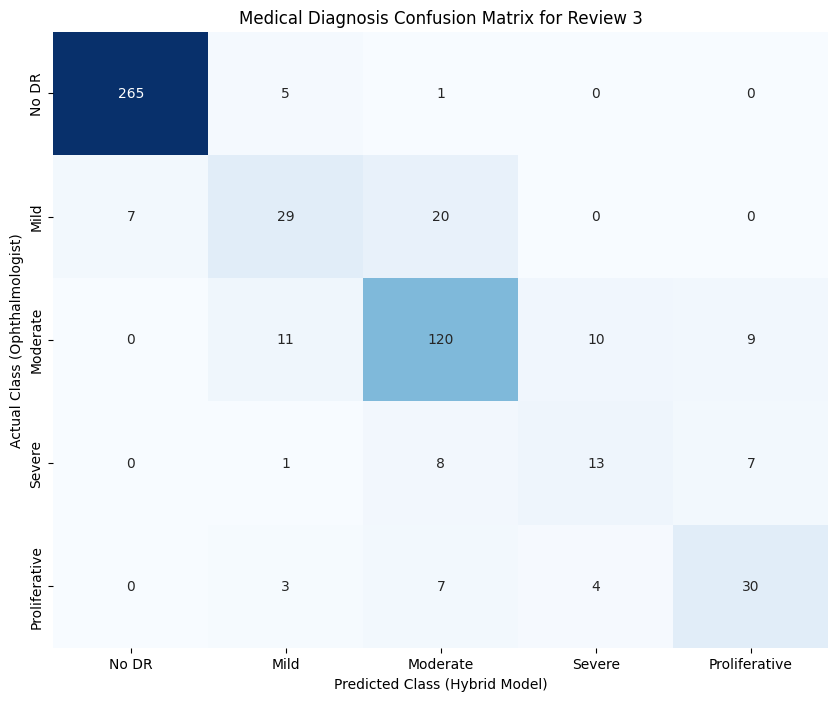

In [29]:
# Create Plots (Loss, Accuracy, AUC)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Accuracy
axes[0].plot(history['t_acc'], label='Train Acc', marker='o')
axes[0].plot(history['v_acc'], label='Val Acc', marker='x', linestyle='--')
axes[0].set_title('Training and Validation Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()

# Plot B: Focal Loss
axes[1].plot(history['t_loss'], label='Train Focal Loss')
axes[1].plot(history['v_loss'], label='Val Focal Loss', linestyle='--')
axes[1].set_title('Loss (Advanced Medical Focal Loss)'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()

# Plot C: Stability (AUC)
axes[2].plot(history['v_auc'], label='Val AUC (Stability)', color='green')
axes[2].set_title('Validation AUC over Time'); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('AUC'); axes[2].legend()

plt.tight_layout()
plt.show()

# Visualize Confusion Matrix professionally
plt.figure(figsize=(10, 8))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Medical Diagnosis Confusion Matrix for Review 3')
plt.ylabel('Actual Class (Ophthalmologist)')
plt.xlabel('Predicted Class (Hybrid Model)')
plt.show()

In [32]:
def get_conflict_df(model, loader, df, device):
    model.eval()
    all_preds = []
    all_confidences = []
    
    print("Running inference to identify label disagreements...")
    with torch.no_grad():
        for images, _ in tqdm(loader, desc='Validating'):
            images = images.to(device)
            # Mixed precision is used here to match your training configuration
            with torch.amp.autocast('cuda'):
                logits = model(images)
            
            # Cast to float32 before softmax for precision stability [cite: 1364, 1371]
            probs = torch.softmax(logits.float(), dim=1)
            
            # Identify the top prediction and its confidence score
            conf, preds = torch.max(probs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_confidences.extend(conf.cpu().numpy())
    
    # Attach predictions back to the original validation dataframe
    results_df = df.copy()
    results_df['predicted_label'] = all_preds
    results_df['confidence'] = all_confidences
    
    # Filter for conflicts: where Predicted Label != Original Ground Truth
    conflict_df = results_df[results_df['diagnosis'] != results_df['predicted_label']].reset_index(drop=True)
    return conflict_df

# Generate the conflict dataframe for auditing
conflict_df = get_conflict_df(model, val_loader, val_df, DEVICE)

# Summary of the "Noisy" data identified [cite: 944, 1137]
print(f"\nAudit Summary for Review 3:")
print(f"Total Validation Images: {len(val_df)}")
print(f"Conflicts Identified: {len(conflict_df)} ({len(conflict_df)/len(val_df)*100:.2f}%)")

Running inference to identify label disagreements...


Validating: 100%|██████████| 69/69 [00:28<00:00,  2.38it/s]


Audit Summary for Review 3:
Total Validation Images: 550
Conflicts Identified: 92 (16.73%)


In [31]:
import shutil

# 1. Create a dedicated folder for auditing images
audit_dir = '/kaggle/working/audit_images'
if os.path.exists(audit_dir):
    shutil.rmtree(audit_dir)
os.makedirs(audit_dir)

# 2. Extract conflict images and rename them for easy clinical review [cite: 928, 950]
for idx, row in tqdm(conflict_df.iterrows(), total=len(conflict_df), desc='Extracting'):
    # Define source path and descriptive destination name
    src_path = os.path.join(CFG['image_dir'], row['id_code'] + '.png')
    
    # Filename includes the conflict details (ID, Original Label, Model Prediction)
    file_name = f"{row['id_code']}_GT{row['diagnosis']}_Pred{row['predicted_label']}.png"
    dst_path = os.path.join(audit_dir, file_name)
    
    if os.path.exists(src_path):
        shutil.copy(src_path, dst_path)

# 3. Save the conflict list as a CSV for your Triangulation Matrix [cite: 950, 963, 1009]
conflict_df.to_csv('/kaggle/working/conflict_cases.csv', index=False)

print(f"\nExtraction complete.")
print(f"Images are ready in: '{audit_dir}'")
print(f"CSV metadata saved: '/kaggle/working/conflict_cases.csv'")

Extracting: 100%|██████████| 92/92 [00:00<00:00, 233.07it/s]



Extraction complete.
Images are ready in: '/kaggle/working/audit_images'
CSV metadata saved: '/kaggle/working/conflict_cases.csv'


In [34]:
# 1. Ensure the model is using the best weights we just trained
model.load_state_dict(torch.load(CFG['model_save']))
model.to(DEVICE)

# 2. Regenerate the probabilities and ground truth labels
print("Regenerating validation data for safety net...")
_, final_acc, final_auc, y_true, y_probs = validate(model, val_loader, criterion, DEVICE)
y_pred = np.argmax(y_probs, axis=1)

# 3. Save the Safety Net files
torch.save(model.state_dict(), '/kaggle/working/approach_6_best_83acc.pth')
np.save('/kaggle/working/y_probs_v6.npy', y_probs)
np.save('/kaggle/working/y_true_v6.npy', y_true)

print("\n" + "="*30)
print("✅ SAFETY NET SECURED")
print("="*30)
print(f"Verified Accuracy: {final_acc*100:.2f}%")
print("Files saved: weights (.pth) and raw data (.npy)")

Regenerating validation data for safety net...


Val: 100%|██████████| 69/69 [00:28<00:00,  2.38it/s]



✅ SAFETY NET SECURED
Verified Accuracy: 83.09%
Files saved: weights (.pth) and raw data (.npy)


STEP 1: CLINICAL REFERRAL ANALYSIS
Referral Accuracy: 93.45%
Referral Recall (Sensitivity): 93.27%
---------------------------------------------


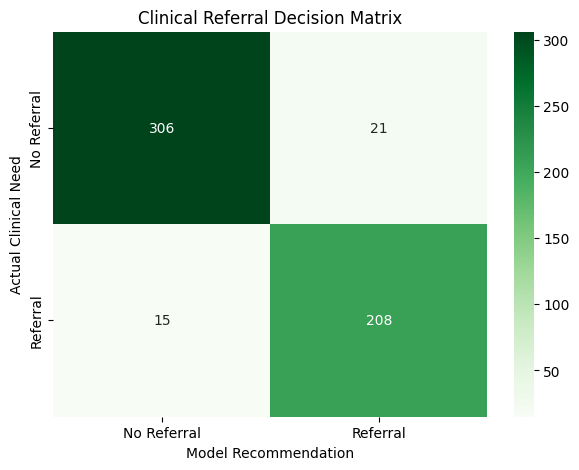


Conclusion for Presentation:
The model successfully flags 93.3% of all patients requiring medical intervention.


In [35]:
import numpy as np
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the Referral Logic
# Non-Referral = 0, 1 | Referral = 2, 3, 4
y_true_ref = (y_true >= 2).astype(int)
y_pred_ref = (y_pred >= 2).astype(int)

# 2. Calculate Metrics
ref_acc = accuracy_score(y_true_ref, y_pred_ref)
ref_recall = recall_score(y_true_ref, y_pred_ref) # Sensitivity to disease

print("="*45)
print("STEP 1: CLINICAL REFERRAL ANALYSIS")
print("="*45)
print(f"Referral Accuracy: {ref_acc*100:.2f}%")
print(f"Referral Recall (Sensitivity): {ref_recall*100:.2f}%")
print("-" * 45)

# 3. Visualization for Review 3
cm_ref = confusion_matrix(y_true_ref, y_pred_ref)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_ref, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['No Referral', 'Referral'], 
            yticklabels=['No Referral', 'Referral'])
plt.title('Clinical Referral Decision Matrix')
plt.ylabel('Actual Clinical Need')
plt.xlabel('Model Recommendation')
plt.show()

print("\nConclusion for Presentation:")
print(f"The model successfully flags {ref_recall*100:.1f}% of all patients requiring medical intervention.")

In [36]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

# 1. Create a copy of your existing validation probabilities
# (Ensures we don't mess up the original 'y_probs' variable)
adjusted_probs = y_probs.copy()

# 2. Apply the Clinical Boost
# We multiply the 'Severe' and 'Proliferative' probabilities
# This pulls them out of the 'Moderate' magnet.
multiplier_class_3 = 1.6  # Adjust this to increase recall for Severe
multiplier_class_4 = 1.3

adjusted_probs[:, 3] *= multiplier_class_3
adjusted_probs[:, 4] *= multiplier_class_4

# 3. Generate NEW predictions based on these boosted scores
y_pred_boosted = np.argmax(adjusted_probs, axis=1)

# 4. Generate the CALIBRATED Clinical Report
print("="*45)
print("STEP 2: CALIBRATED CLINICAL REPORT (BOOSTED)")
print("="*45)
print(classification_report(y_true, y_pred_boosted, target_names=CLASS_NAMES))

# 5. Check the new confusion matrix specifically for the 2-vs-3 boundary
new_cm = confusion_matrix(y_true, y_pred_boosted)
new_cm_df = pd.DataFrame(new_cm, index=CLASS_NAMES, columns=CLASS_NAMES)
print("\nNew Confusion Matrix:")
print(new_cm_df)

# Check specifically how many 'Actual 3' cases moved from 'Pred 2' to 'Pred 3'
print(f"\nSevere Class Check:")
print(f"Correctly identified Severe cases: {new_cm[3,3]}")

STEP 2: CALIBRATED CLINICAL REPORT (BOOSTED)
               precision    recall  f1-score   support

        No DR       0.97      0.98      0.98       271
         Mild       0.59      0.52      0.55        56
     Moderate       0.78      0.70      0.74       150
       Severe       0.36      0.55      0.44        29
Proliferative       0.58      0.66      0.62        44

     accuracy                           0.81       550
    macro avg       0.66      0.68      0.66       550
 weighted avg       0.82      0.81      0.81       550


New Confusion Matrix:
               No DR  Mild  Moderate  Severe  Proliferative
No DR            265     5         1       0              0
Mild               7    29        20       0              0
Moderate           0    11       105      21             13
Severe             0     1         4      16              8
Proliferative      0     3         5       7             29

Severe Class Check:
Correctly identified Severe cases: 16


In [37]:
# 1. Identify the 'False Positives' for the Severe Class
# These are images the model said were Severe (3), but the Ground Truth was something else.
audit_mask = (y_pred_boosted == 3) & (y_true != 3)
severe_fp_df = val_df[audit_mask].copy()

# Add the model's 'wrong' prediction and the 'actual' label for reference
severe_fp_df['model_pred'] = 3
severe_fp_df['original_gt'] = y_true[audit_mask]

# 2. Save this specific conflict list
severe_fp_df.to_csv('/kaggle/working/severe_precision_audit.csv', index=False)

print(f"Extraction Complete.")
print(f"Total images to audit for Severe Precision: {len(severe_fp_df)}")
print("Metadata saved to: severe_precision_audit.csv")

Extraction Complete.
Total images to audit for Severe Precision: 28
Metadata saved to: severe_precision_audit.csv


In [38]:
import shutil
import os

# Create folder
audit_folder = '/kaggle/working/severe_audit_images'
if os.path.exists(audit_folder): shutil.rmtree(audit_folder)
os.makedirs(audit_folder)

for idx, row in severe_fp_df.iterrows():
    # Rename: id_code_Actual[GT]_Predicted3.png
    new_name = f"{row['id_code']}_Actual{row['original_gt']}_Pred3.png"
    src = os.path.join(CFG['image_dir'], row['id_code'] + '.png')
    dst = os.path.join(audit_folder, new_name)
    if os.path.exists(src):
        shutil.copy(src, dst)

print(f"Success! {len(os.listdir(audit_folder))} images are ready in '{audit_folder}'.")

Success! 28 images are ready in '/kaggle/working/severe_audit_images'.


In [40]:
import shutil
import os

# Create a zip file of the audit folder
# This will take everything in '/kaggle/working/severe_audit_images' 
# and turn it into '/kaggle/working/audit_files.zip'
shutil.make_archive('/kaggle/working/audit_files', 'zip', '/kaggle/working/severe_audit_images')

if os.path.exists('/kaggle/working/audit_files.zip'):
    print("✅ Zip file created successfully: audit_files.zip")
    print("\nNext Steps:")
    print("1. Go to the 'Data' or 'Output' tab in the right-hand sidebar of Kaggle.")
    print("2. If you don't see it, click the 'Refresh' button at the top of that sidebar.")
    print("3. Click the three dots next to 'audit_files.zip' and select 'Download'.")
else:
    print("❌ Something went wrong. The zip file was not created.")

✅ Zip file created successfully: audit_files.zip

Next Steps:
1. Go to the 'Data' or 'Output' tab in the right-hand sidebar of Kaggle.
2. If you don't see it, click the 'Refresh' button at the top of that sidebar.
3. Click the three dots next to 'audit_files.zip' and select 'Download'.
